<a href="https://colab.research.google.com/github/Khalimovgeek/Kaggle_tesnorflow_trainings/blob/main/Transfer_Learning_with_ResNet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install tensorflow
!pip install tensorflow-datasets

In [ ]:
!pip install --upgrade protobuf

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 327.1/327.1 kB 10.2 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 5.29.6
    Uninstalling protobuf-5.29.6:
      Successfully uninstalled protobuf-5.29.6
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-ai-generativelanguage 0.6.15 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<6.0.0dev,>=3.20.2, but you have protobuf 7.35.1 which is incompatible.
ydf 0.15.0 requires protobuf<7.0.0,>=5.29.1, but you have protobuf 7.35.1 which is incompatible.
grpcio-status 1.71.2 requires protobuf<6.0dev,>=5.26.1, but you have protobuf 7.35.1 which is incompatible.


In [78]:
import tensorflow as tf
import tensorflow_datasets as tfds
from tensorflow.keras  import layers, models,utils
from matplotlib import pyplot as plt
import numpy as np
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

In [79]:
splits = ['train[:80%]', 'train[80%:]']
dataset = tfds.load('tf_flowers', as_supervised=True , split= splits)
train_dataset, test_dataset = dataset
train_dataset = train_dataset.map(lambda image, label: (preprocess_input(tf.image.resize(image, (224, 224))), label))
test_dataset = test_dataset.map(lambda image, label: (preprocess_input(tf.image.resize(image, (224, 224))), label))
train_dataset = train_dataset.batch(32)
test_dataset = test_dataset.batch(32)
train_dataset = train_dataset.prefetch(tf.data.AUTOTUNE)
test_dataset = test_dataset.prefetch(tf.data.AUTOTUNE)

In [80]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)

In [81]:
base_model.trainable = False

In [82]:
def newModel():
  model = models.Sequential(
      [
          base_model,
          layers.GlobalAveragePooling2D(),
          layers.Dense(128, activation='relu'),
          layers.Dropout(0.5),
          layers.Dense(5, activation='softmax')

      ]
  )
  return model

custom_model = newModel()
custom_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

custom_model.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_7      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,597 (9.24 MB)

 Trainable params: 164,613 (643.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [83]:
history = custom_model.fit(
    train_dataset,
    validation_data=test_dataset,
    epochs=10
)

Epoch 1/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 34s 261ms/step - accuracy: 0.7364 - loss: 0.7322 - val_accuracy: 0.8842 - val_loss: 0.3379
Epoch 2/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - accuracy: 0.8515 - loss: 0.4004 - val_accuracy: 0.8951 - val_loss: 0.3056
Epoch 3/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - accuracy: 0.8883 - loss: 0.3134 - val_accuracy: 0.8978 - val_loss: 0.2791
Epoch 4/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 4s 42ms/step - accuracy: 0.9121 - loss: 0.2438 - val_accuracy: 0.8924 - val_loss: 0.2700
Epoch 5/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - accuracy: 0.9285 - loss: 0.2013 - val_accuracy: 0.9101 - val_loss: 0.2529
Epoch 6/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - accuracy: 0.9493 - loss: 0.1650 - val_accuracy: 0.9019 - val_loss: 0.2671
Epoch 7/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - accuracy: 0.9489 - loss: 0.1541 - val_accuracy: 0.9046 - val_loss: 0.2533
Epoch 8/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 4s 40ms/step - accuracy: 0.9533 - loss: 0.1292 - val_accuracy: 0.9128 -

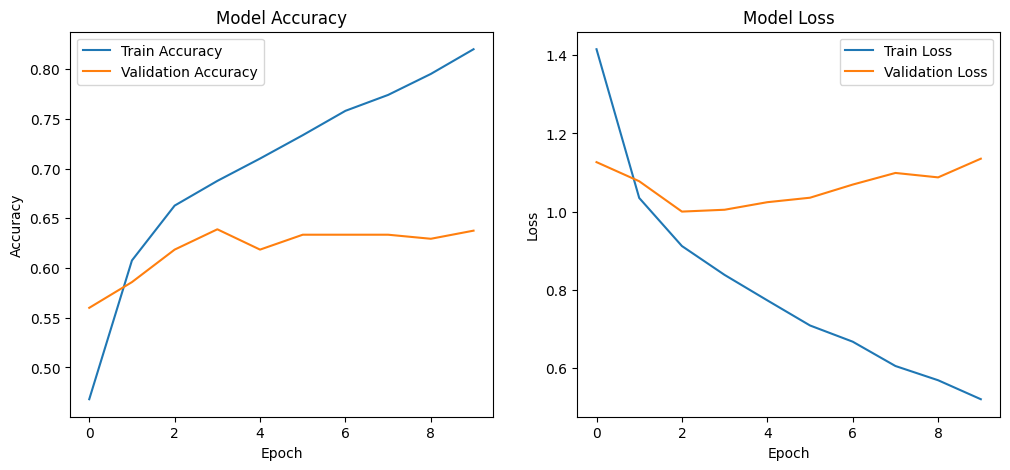

In [35]:
plt.figure(figsize=(12,5))


plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()


plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

In [42]:
model_path = "/content/flowers_model1.keras"
loaded_model = tf.keras.models.z(model_path)

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 322 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [60]:
# Note the added 'with_info=True' and the extra 'info' variable
dataset, info = tfds.load('tf_flowers', as_supervised=True, split=splits, with_info=True)

# Access the class names from 'info'
class_names = info.features['label'].names
print(class_names)

['dandelion', 'daisy', 'tulips', 'sunflowers', 'roses']


In [76]:
img = tf.keras.utils.load_img("/content/images.webp", target_size=(224, 224))
img_array = tf.keras.utils.img_to_array(img)
img_array = tf.expand_dims(img_array, axis=0)
predictions = loaded_model.predict(img_array)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step


In [77]:
predicted_class_index = tf.argmax(predictions[0]).numpy()
print("Predicted Class Index:", predicted_class_index)

Predicted Class Index: 2


In [58]:
custom_model.save('flowers_model1.keras')
